In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# load sepsis dataset and perform initial sanity checks
def load_sepsis_data(file_path):
    # Load the dataset
    sepsis_df = pd.read_csv(file_path)

    # Display basic information about the dataset
    print("Dataset Info:")
    print(sepsis_df.info())

    # Display first few rows of the dataset
    print("\nFirst 5 rows of the dataset:")
    print(sepsis_df.head())
    
    # Summary statistics
    print("\nSummary statistics of the dataset:")
    print(sepsis_df.describe())

    return sepsis_df

In [3]:
sepsis_df = load_sepsis_data('/Volumes/ExtremeSSD/Projects/agentic-sepsis-patient-similarity/data/Dataset.csv')
#summarize columns, types and missing value percentages. do not create separate function.
print("\nColumn Summary:")
for col in sepsis_df.columns:
    print(f"Column: {col}, Type: {sepsis_df[col].dtype}")
print("\nMissing Value Percentages:")
missing_percentages = (sepsis_df.isnull().sum() / len(sepsis_df)) * 100
for col, pct in missing_percentages.items():
    if pct > 0:
        print(f"Column: {col}, Missing Percentage: {pct:.2f}%")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1552210 non-null  int64  
 1   Hour              1552210 non-null  int64  
 2   HR                1398811 non-null  float64
 3   O2Sat             1349474 non-null  float64
 4   Temp              525226 non-null   float64
 5   SBP               1325945 non-null  float64
 6   MAP               1358940 non-null  float64
 7   DBP               1065656 non-null  float64
 8   Resp              1313875 non-null  float64
 9   EtCO2             57636 non-null    float64
 10  BaseExcess        84145 non-null    float64
 11  HCO3              65028 non-null    float64
 12  FiO2              129365 non-null   float64
 13  pH                107573 non-null   float64
 14  PaCO2             86301 non-null    float64
 15  SaO2              53561 non-null   

Observations:
1. Labs have >75% missingness (null values)
2. Vitals have upto 35-40% missingness with some <15% missing.
3. HSP admission time is not missing.
4. This is expected in ICU setting.

In [4]:
# analyze number of records per patient and timeline lengths
patient_record_counts = sepsis_df['Patient_ID'].value_counts()
print("\nPatient Record Counts Summary:")
patient_counts = sepsis_df.groupby('Patient_ID').size()
patient_counts.describe()


Patient Record Counts Summary:


count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
dtype: float64

### Observations:
1. Total patient count=40336
2. An avg patient has ~38 ICU hours i.e. ~1.6 ICU days.
3. Most patients have non-trivial longitudinal data
4. Std ~22.8 shows high variability in LOS
5. Patient has minimum of 8 time points.
6. 25% patients have <=24 timepoints ~1 day of ICU observations/datapoints.
7. Half the patients have <=38 hours ~1.6 day of ICU observations/datapoints. (median~ mean so symmetrical distribution almost)
8. Most patients cluster between 24-47 hours of data.
9. max = 336: Some patients observed for ~14 days in ICU.
To consolidate these findings, following is the interpretation.


### Interpretation:
#### Patient Timeline Lengths

The dataset contains longitudinal ICU data for approximately 40,000 patients.
Each patient has multiple recorded time points, with a median of 38 observations
per patient and a minimum of 8.

This indicates that most patients have at least one full day of ICU data, while
a subset of patients have very long trajectories extending over multiple days.
The wide distribution of timeline lengths motivates aggregating patient data
into fixed time windows before performing patient similarity analysis or
LLM-based summarization.


In [5]:
# compare number of time points per patient between septic and non-septic patients.
patient_lengths = (
    sepsis_df.groupby(["Patient_ID", "SepsisLabel"])
      .size()
      .reset_index(name="num_timepoints")
)

patient_lengths.groupby("SepsisLabel")["num_timepoints"].describe()

,count,mean,std,min,25%,50%,75%,max
SepsisLabel,,,,,,,,
0,39910.0,38.193285,22.064602,1.0,24.0,38.0,47.0,336.0
1,2932.0,9.521146,0.805069,1.0,9.0,10.0,10.0,10.0


### Observations
1. Only ~3000 patients have sepsis out of the 40000 patients.
2. The ICU stays look shorter for sepsis patients compared to non-septic.

### Class Distribution

Septic patients represent approximately 7–8% of the cohort, consistent with
reported sepsis prevalence in general ICU populations. While this introduces
class imbalance, it reflects real-world clinical distributions and reinforces
the importance of similarity-based reasoning rather than pure classification.

### Sepsis Label Interpretation

Although septic patients are often associated with prolonged ICU stays in
clinical practice, the sepsis-labeled cohort in this dataset exhibits shorter
timelines. This is expected, as sepsis labels are assigned relative to the time
of sepsis onset, and patient trajectories are typically truncated to avoid
post-onset data leakage.

As a result, septic patient records primarily represent early ICU data leading
up to sepsis onset, while non-septic patients retain their full ICU trajectories.
This reinforces the need to perform patient similarity analysis using fixed
early time windows rather than full-length timelines.

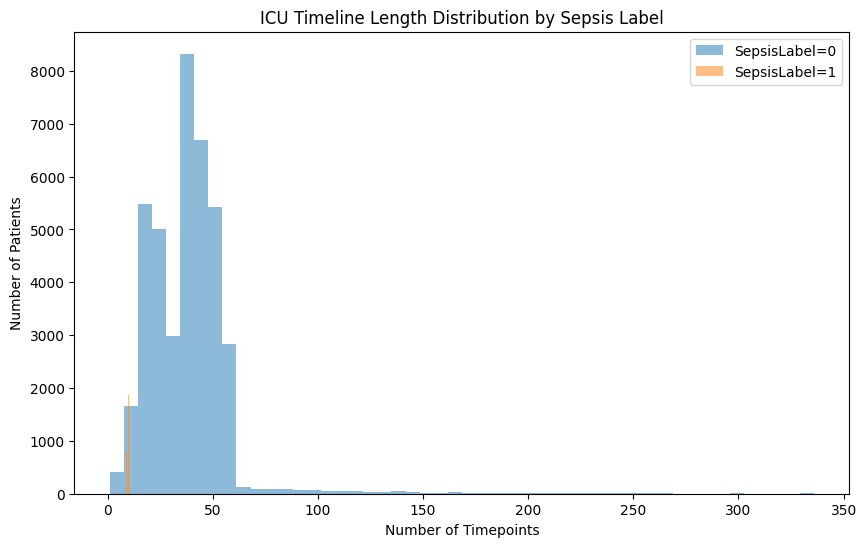

In [6]:
# visualize distribution of timeline lengths by sepsis label use matplotlib

plt.figure(figsize=(10,6))
for label in patient_lengths['SepsisLabel'].unique():
    subset = patient_lengths[patient_lengths['SepsisLabel'] == label]
    plt.hist(subset['num_timepoints'], bins=50, alpha=0.5, label=f'SepsisLabel={label}')
plt.xlabel('Number of Timepoints')
plt.ylabel('Number of Patients')
plt.title('ICU Timeline Length Distribution by Sepsis Label')
plt.legend()
plt.show()

In [7]:
# compare missing data patterns between septic and non-septic patients
missing_data_summary = sepsis_df.groupby('SepsisLabel').apply(lambda x: x.isnull().mean() * 100)
print("\nMissing Data Summary by Sepsis Label:")
print(missing_data_summary) 


Missing Data Summary by Sepsis Label:
             Unnamed: 0  Hour        HR      O2Sat       Temp        SBP  \
SepsisLabel                                                                
0                   0.0   0.0  9.918165  13.110594  66.164664  14.565628   
1                   0.0   0.0  7.941682  10.359650  66.055309  15.195587   

                   MAP        DBP       Resp      EtCO2  ...  Fibrinogen  \
SepsisLabel                                              ...               
0            12.505396  31.372622  15.373084  96.415455  ...   99.349732   
1             9.496346  29.886087  14.343029  89.264221  ...   98.817882   

             Platelets  Age  Gender      Unit1      Unit2  HospAdmTime  \
SepsisLabel                                                              
0            94.088411  0.0     0.0  39.321614  39.321614     0.000525   
1            92.481014  0.0     0.0  45.074509  45.074509     0.000000   

             ICULOS  SepsisLabel  Patient_ID  
SepsisL

/var/folders/vx/q4v5_zdn6sz04xlg4v44hlph0000gn/T/ipykernel_43245/175895436.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_data_summary = sepsis_df.groupby('SepsisLabel').apply(lambda x: x.isnull().mean() * 100)


### Missingness Patterns by Sepsis Status

We examined missing data percentages for all features stratified by sepsis label.
Overall, missingness appears evenly distributed between septic and non-septic patients,
with no feature showing a significant difference between the two groups. 

This suggests that downstream feature engineering or patient similarity analysis
is unlikely to be biased by differential missingness.


/var/folders/vx/q4v5_zdn6sz04xlg4v44hlph0000gn/T/ipykernel_43245/2418737839.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percent_missing', y='feature', data=missing_percent, palette='coolwarm')


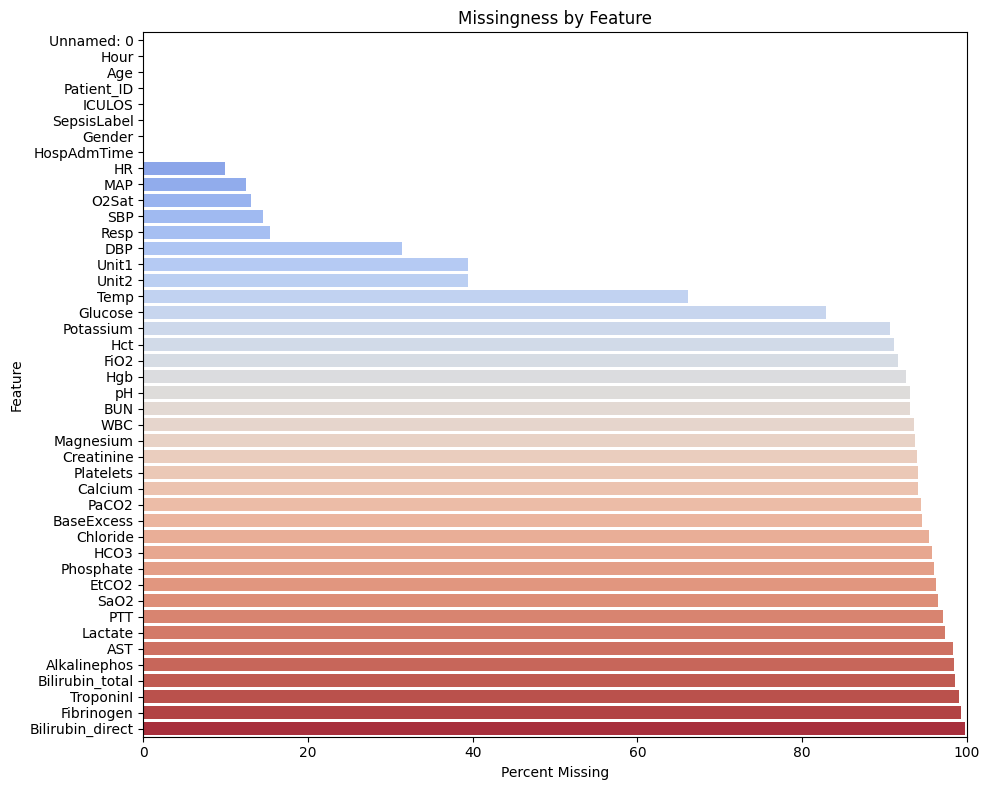

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute percent missing per feature
missing_percent = sepsis_df.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=True).reset_index()
missing_percent.columns = ['feature', 'percent_missing']

# Plot with Seaborn
plt.figure(figsize=(10,8))
sns.barplot(x='percent_missing', y='feature', data=missing_percent, palette='coolwarm')
plt.xlabel('Percent Missing')
plt.ylabel('Feature')
plt.title('Missingness by Feature')
plt.xlim(0, 100)  
plt.tight_layout()
plt.show()


/var/folders/vx/q4v5_zdn6sz04xlg4v44hlph0000gn/T/ipykernel_43245/2662248747.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


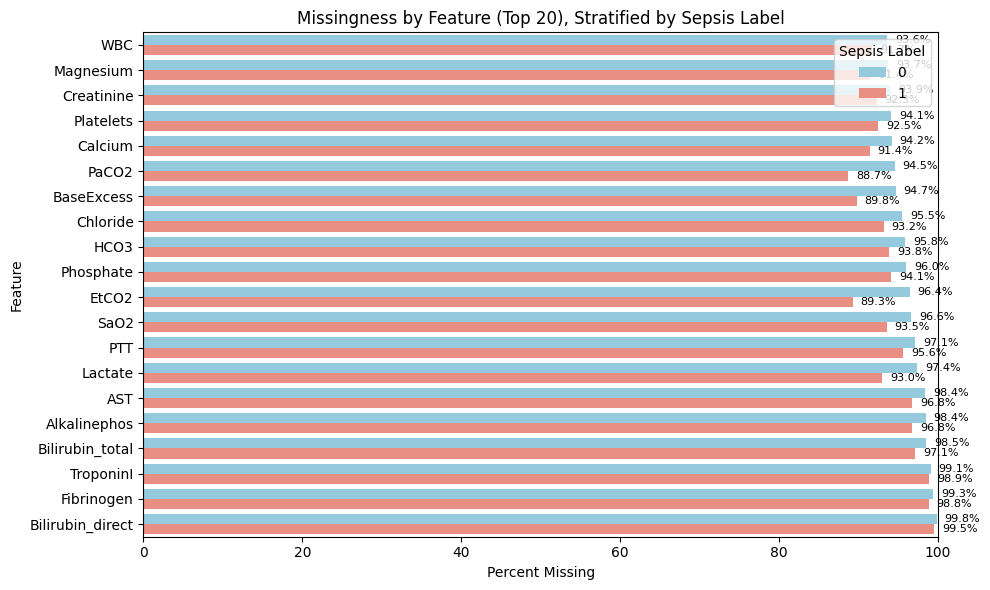

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute missingness per feature by SepsisLabel

missing_per_label = (
    sepsis_df.groupby('SepsisLabel')
      .apply(lambda x: x.isna().mean())
      .T
      .reset_index()
      .melt(id_vars='index', var_name='SepsisLabel', value_name='percent_missing')
)
missing_per_label.rename(columns={'index': 'feature'}, inplace=True)
missing_per_label['percent_missing'] *= 100  # convert to %

# Optional: Limit to Top N features by overall missingness for readability
top_n = 20
feature_order = sepsis_df.isna().mean().sort_values(ascending=False).head(top_n).index
missing_per_label = missing_per_label[missing_per_label['feature'].isin(feature_order)]


# Plot: Horizontal barplot, stratified by SepsisLabel
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='percent_missing',
    y='feature',
    hue='SepsisLabel',
    data=missing_per_label,
    palette=['skyblue', 'salmon'],
    order=feature_order[::-1]  # top-down
)

plt.xlabel('Percent Missing')
plt.ylabel('Feature')
plt.title('Missingness by Feature (Top 20), Stratified by Sepsis Label')
plt.legend(title='Sepsis Label', loc='upper right')
plt.xlim(0, 100)  # consistent scale

# Add aligned value labels on bars
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width > 0:  # optional: only label bars with >0% missing
        ax.text(width + 1, y, f"{width:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()


### Observation: 
Missingness is evenly distributed across septic and non-septic patients,
supporting unbiased feature engineering and patient similarity analysis.